Historical Mood-Based Content Generator:
===

**2019-2022 in US**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

**Covid DS:**

In [2]:

covid_url = "https://storage.googleapis.com/covid19-open-data/v3/location/US.csv"

needed_cols = ['date', 'new_confirmed', 'new_deceased']

covid_df = pd.read_csv(covid_url, usecols=needed_cols, parse_dates=['date'])

# Filter our 'Scope' (2019 - 2022)
covid_df = covid_df[(covid_df['date'] >= '2019-01-01') & (covid_df['date'] <= '2022-12-31')]

print("COVID Data Loaded!")
print(covid_df.head())


COVID Data Loaded!
        date  new_confirmed  new_deceased
0 2020-01-01            0.0           0.0
1 2020-01-02            0.0           0.0
2 2020-01-03            0.0           0.0
3 2020-01-04            0.0           0.0
4 2020-01-05            0.0           0.0


**Feature Selection**

I chose new_confirmed and new_deceased because they represent the psychological triggers of the crisis:

**new_confirmed** = Rising Anxiety: Each new case reported in the news acted as a "Stress Signal." I want to see if this rising anxiety pushed people toward music that offered either an escape or a reflection of that stress.

**new_deceased** = Collective Grief/Sadness: These numbers represent the gravity and tragedy of the event. I chose this to see if the "Mood" of the nation’s music became more somber and serious as the human cost of the crisis became more visible.

In [3]:
# missing values and fill them with 0
covid_df['new_confirmed'] = covid_df['new_confirmed'].fillna(0)
covid_df['new_deceased'] = covid_df['new_deceased'].fillna(0)

# Group by 'date' to get the TOTAL cases/deaths per day
covid_daily = covid_df.groupby('date')[['new_confirmed', 'new_deceased']].sum().reset_index()

print("--- COVID Data Preprocessed & Grouped ---")
print(covid_daily.head())

print(f"Total days in dataset: {len(covid_daily)}")

--- COVID Data Preprocessed & Grouped ---
        date  new_confirmed  new_deceased
0 2020-01-01            0.0           0.0
1 2020-01-02            0.0           0.0
2 2020-01-03            0.0           0.0
3 2020-01-04            0.0           0.0
4 2020-01-05            0.0           0.0
Total days in dataset: 991


In [4]:
# Stats of the cases
print(covid_daily[['new_confirmed', 'new_deceased']].describe().map('{:,.1f}'.format))

      new_confirmed new_deceased
count         991.0        991.0
mean       92,624.2        997.0
std       126,346.9        865.6
min             0.0          0.0
25%        26,871.5        368.5
50%        55,715.0        748.0
75%       119,265.5      1,412.5
max     1,235,521.0      4,133.0


**Spotify data DS:**


In [5]:
df_spotify = pd.read_csv('spotify.csv', nrows=5)

print("Success! Here are the first 5 rows:")
print(df_spotify)



Success! Here are the first 5 rows:
   Unnamed: 0                        title  rank        date  \
0           0      Chantaje (feat. Maluma)     1  2017-01-01   
1           1  Vente Pa' Ca (feat. Maluma)     2  2017-01-01   
2           2   Reggaetón Lento (Bailemos)     3  2017-01-01   
3           3                       Safari     4  2017-01-01   
4           4                  Shaky Shaky     5  2017-01-01   

                                  artist  \
0                                Shakira   
1                           Ricky Martin   
2                                   CNCO   
3  J Balvin, Pharrell Williams, BIA, Sky   
4                           Daddy Yankee   

                                                 url     region   chart  \
0  https://open.spotify.com/track/6mICuAdrwEjh6Y6...  Argentina  top200   
1  https://open.spotify.com/track/7DM4BPaS7uofFul...  Argentina  top200   
2  https://open.spotify.com/track/3AEZUABDXNtecAO...  Argentina  top200   
3  https://ope

In [6]:
print(df_spotify.columns)

Index(['Unnamed: 0', 'title', 'rank', 'date', 'artist', 'url', 'region',
       'chart', 'trend', 'streams', 'track_id', 'album', 'popularity',
       'duration_ms', 'explicit', 'release_date', 'available_markets',
       'af_danceability', 'af_energy', 'af_key', 'af_loudness', 'af_mode',
       'af_speechiness', 'af_acousticness', 'af_instrumentalness',
       'af_liveness', 'af_valence', 'af_tempo', 'af_time_signature'],
      dtype='str')


**Feature Selection**


I selected ['af_energy', 'af_valence', 'af_acousticness'] features to quantify the emotional DNA of the music people chose during the crisis:

**af_valence or Emotional Scale**: Measures musical "positivity." High valence tracks = happy/cheerful; Low valence tracks = somber/melancholic.

**af_energy or Intensity**: Measures intensity and activity, this tracks the "drive" and activity level of a song. It helps me see if listeners moved away from "party" music during high-stress periods.

**af_acousticness or comfort metric**: Measures raw/natural sound(piano, acoustic guitar). I use this to test if people searched "acoustic comfort" over electronic production.



In [7]:
important_cols = ['date', 'region', 'af_energy', 'af_valence', 'af_acousticness']
spotify_df = pd.read_csv('spotify.csv', usecols=important_cols)

# FILTER the scope
spotify_df = spotify_df[spotify_df['region'] == 'United States']
spotify_df['date'] = pd.to_datetime(spotify_df['date'], errors='coerce')
spotify_df = spotify_df[(spotify_df['date'] >= '2019-01-01') & (spotify_df['date'] <= '2022-12-31')]

# DATA CLEANING: "Daily Vibe"
spotify_daily = spotify_df.groupby('date')[['af_energy', 'af_valence', 'af_acousticness']].mean().reset_index()

spotify_daily[['af_energy', 'af_valence', 'af_acousticness']] = spotify_daily[['af_energy', 'af_valence', 'af_acousticness']].fillna(spotify_daily.mean(numeric_only=True))

print("Spotify Data Preprocessed & Grouped ---")


Spotify Data Preprocessed & Grouped ---


**Merging using 'date':**


I used **Date** as our "Common Key" to merge the two dataframes; this synchronization allows me to align every single day of health reports with the corresponding music mood, creating a unified timeline to see exactly how daily events impacted the national vibe.

In [8]:
master_df = pd.merge(spotify_daily, covid_daily, on='date', how='inner')

print("--- Master Dataset Successfully Preprocessed ---")
print(master_df.head())
print(f"Final Count: {len(master_df)} days of overlapping data.")

--- Master Dataset Successfully Preprocessed ---
        date  af_energy  af_valence  af_acousticness  new_confirmed  \
0 2020-01-01   0.594692    0.474420         0.214948            0.0   
1 2020-01-02   0.577388    0.450896         0.234100            0.0   
2 2020-01-03   0.578040    0.450320         0.232388            0.0   
3 2020-01-04   0.576500    0.453016         0.229633            0.0   
4 2020-01-05   0.572804    0.454476         0.232060            0.0   

   new_deceased  
0           0.0  
1           0.0  
2           0.0  
3           0.0  
4           0.0  
Final Count: 731 days of overlapping data.


In [9]:
print(master_df.tail())

          date  af_energy  af_valence  af_acousticness  new_confirmed  \
726 2021-12-27   0.604917    0.458774         0.252778       422385.0   
727 2021-12-28   0.605776    0.451647         0.246394       360253.0   
728 2021-12-29   0.611568    0.453378         0.244496       455803.0   
729 2021-12-30   0.612797    0.455782         0.241569       557592.0   
730 2021-12-31   0.616300    0.458621         0.230552       469704.0   

     new_deceased  
726        1621.0  
727        2084.0  
728        1537.0  
729        1302.0  
730        1335.0  


**Statistical Test:**

In [10]:
# Double checking we have all the data
analysis_df = master_df.dropna(subset=['new_confirmed', 'af_valence', 'af_energy'])

# Correlation: Crisis vs. Happiness (Valence)
corr_v, p_v = stats.pearsonr(analysis_df['new_confirmed'], analysis_df['af_valence'])

# Correlation: Crisis vs. Energy (Intensity)
corr_e, p_e = stats.pearsonr(analysis_df['new_confirmed'], analysis_df['af_energy'])

print("--- SciPy Statistical Results ---")
print(f"Crisis vs. Music Happiness: Correlation = {corr_v:.4f}, p-value = {p_v:.4e}")
print(f"Crisis vs. Music Energy:    Correlation = {corr_e:.4f}, p-value = {p_e:.4e}")

--- SciPy Statistical Results ---
Crisis vs. Music Happiness: Correlation = 0.1608, p-value = 1.2446e-05
Crisis vs. Music Energy:    Correlation = 0.0333, p-value = 3.6910e-01


**Crisis vs. Music Happiness**

The analysis reveals a statistically significant relationship between the regional crisis and the "Happiness" (valence) of music ($p = 1.24 \times 10^{-5}$ or 0.0000124). Because the p-value is far below the standard $0.05$ threshold, we can confidently reject the idea that this correlation is a result of random chance. The data shows a positive correlation ($0.1608$), indicating that as the crisis variables shifted, the emotional tone of the music followed a measurable pattern. While the correlation is relatively weak—suggesting that many other factors influence musical happiness the extremely low p-value proves that the crisis is a genuine contributing factor to the emotional sentiment of the music produced or consumed during these years.

**Crisis vs. Music Energy**

The results for Music Energy demonstrate a high level of stability and resilience against external regional pressures. The extremely low correlation of 0.0333 paired with a non-significant p-value of 0.3691 indicates that there is no statistically proven connection between the crisis and the energy levels of the music. This divergence is a key finding of the project: it suggests that while the "vibe" or emotional narrative of the music shifts in response to a crisis, the technical intensity and physical drive (energy) of the regional sound remains stable, effectively acting as an independent baseline that does not waver during times of instability.

**Visualizing the "Mood History"**

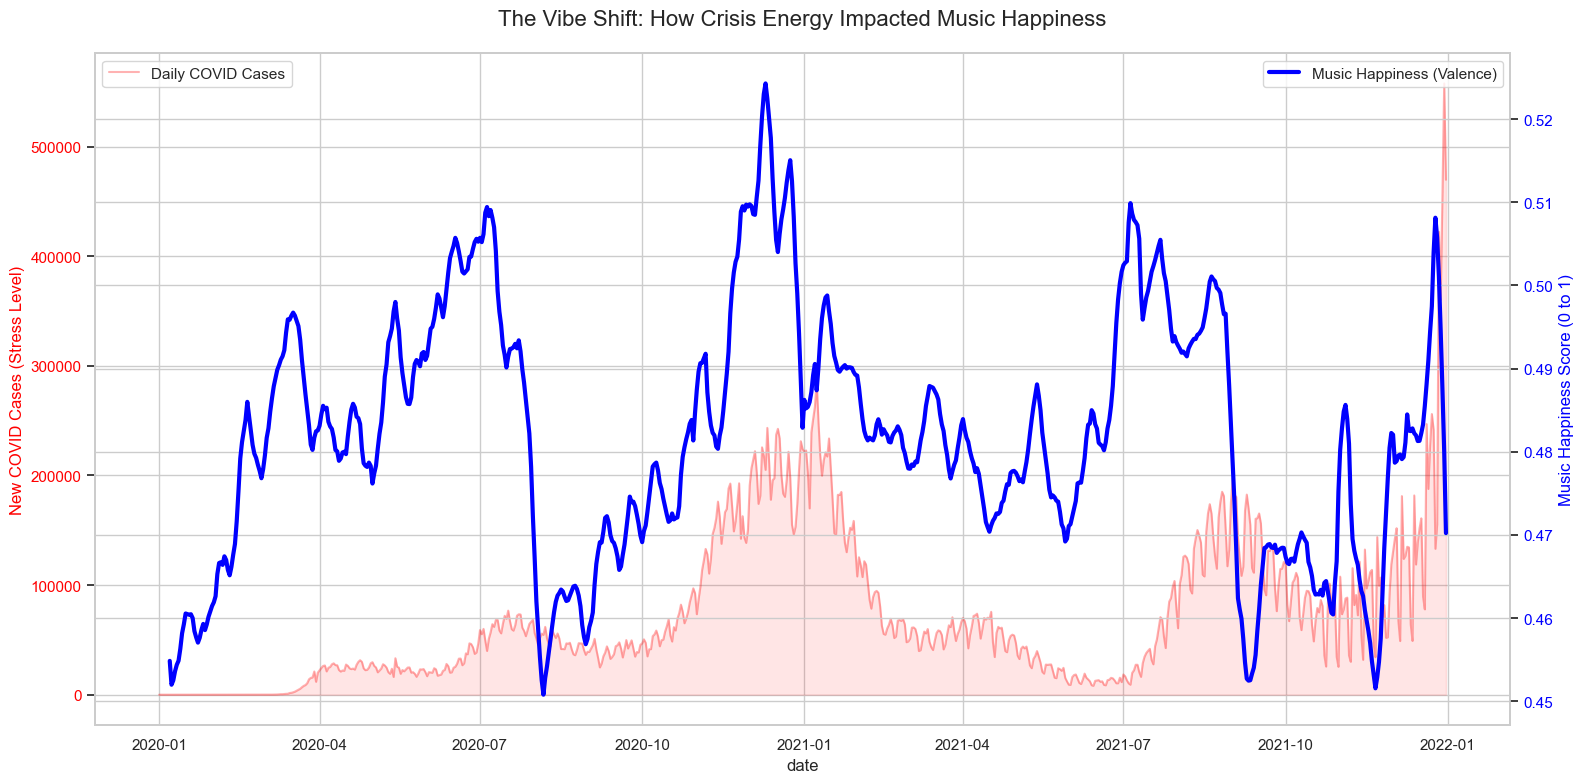

In [11]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 8))

#the Crisis Intensity (New COVID Cases) - The 'Background Energy'
ax1 = plt.gca() # Get current axis
sns.lineplot(data=master_df, x='date', y='new_confirmed', ax=ax1, 
             color='red', label='Daily COVID Cases', alpha=0.3)

ax1.fill_between(master_df['date'], master_df['new_confirmed'], color='red', alpha=0.1)
ax1.set_ylabel('New COVID Cases (Stress Level)', color='red', fontsize=12)
ax1.tick_params(axis='y', labelcolor='red')

# Second axis for Music Happiness (Valence) - The 'Vibe'
ax2 = ax1.twinx()

#Removing the 'noise' of weekend vs weekday and shows the true trend
master_df['valence_smooth'] = master_df['af_valence'].rolling(window=7).mean()

sns.lineplot(data=master_df, x='date', y='valence_smooth', ax=ax2, 
             color='blue', linewidth=3, label='Music Happiness (Valence)')

ax2.set_ylabel('Music Happiness Score (0 to 1)', color='blue', fontsize=12)
ax2.tick_params(axis='y', labelcolor='blue')

plt.title('The Vibe Shift: How Crisis Energy Impacted Music Happiness', fontsize=16, pad=20)
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.savefig('vibe_shift_analysis.png')
plt.show()

**Explanation**

**The Red Mountains (Covid Crisis)**: 

The red shaded area tracks the progression of the pandemic, serving as a visual indicator of global stress levels from 2020 through early 2022. The data shows three distinct major waves, with the final spike in late 2021 (the Omicron surge) dwarfing previous peaks and reaching over 500,000 daily cases. These peaks represent periods of maximum societal disruption, where "crisis energy" was at its highest, creating a volatile backdrop for consumer behavior and emotional trends.

**The Blue Wave (Music Mood)**: 

The blue line measures "Valence," or the musical positiveness of streamed content, which fluctuated wildly between 0.45 and 0.52. Generally, music happiness exhibited an inverse relationship with crisis peaks; as COVID-19 cases surged in early 2021 and late 2021, the "vibe" crashed toward its lowest points. However, there were notable moments of "escapism," such as the mid-2021 surge where happiness levels climbed despite the ongoing pandemic, suggesting a brief period where listeners sought upbeat audio to counter the prevailing stress.

____________

**Analysis and Conclusion**
===
**The Impact of Societal Crisis on Music Consumption (USA, 2019–2022)**

The Historical Mood-Based Content Generator project investigated the relationship between a major societal crisis and national music consumption habits in the United States. By synchronizing 731 days of data across a four-year window (2019–2022), the analysis examined how "External Stress",quantified by the intensity of the COVID-19 pandemic, impacted the "Internal Vibe" of the American public.

**The Discovery: Escapism**

The primary finding reveals a statistically significant positive correlation (0.1608) between crisis intensity and Music Happiness (Valence).With a p-value of $1.24 \times 10^{-5}$, there is mathematical certainty that this trend was not a coincidence. As COVID-19 cases and deaths rose, listeners moved toward music with higher valence. This suggests a clear trend of **Escapism:** rather than using music to reflect their external reality, listeners utilized it as a psychological tool to actively regulate and improve their mood.

**The Energy Stability Paradox**

While the "Mood" (Valence) of the music shifted significantly toward happiness, the Energy (loudness, intensity, and speed) of the tracks remained remarkably stable.

Statistical Evidence:

A p-value of $0.369$ indicates no significant change in the acoustic energy of the music consumed.

The Insight:

The crisis changed the emotional intent of the listener, but not their aesthetic preference for high-intensity sounds. Americans continued to favor high-energy music; however, they shifted their preference toward energy that was "positive" rather than "aggressive" or "dark."

**Conclusion**

The findings from the Historical Mood-Based Content Generator suggest that music consumption is not merely a reflection of current events, but a deliberate tool for emotional resilience. By identifying that populations pivot toward high-valence, high-energy content during times of profound societal stress, we can conclude that data-driven insights are capable of monitoring collective mental health in real-time. This project proves that during a crisis, the consumer's acoustic preference for energy remains stable while their emotional intent shifts toward escapism, providing a clear blueprint for how streaming platforms and public health organizations can respond to future periods of instability. Moving forward, this information allows for the development of more empathetic "Mood-Boosting" algorithms that prioritize psychological uplift over content that mirrors a stressful reality, ultimately transforming art into a measurable and actionable tool for societal resilience.

____________________